In [1]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#parameters

### USER EDIT start
run_dir = '/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params'
esm_file= os.path.join(run_dir, 'cm3-demo-datastore/cm3-demo-datastore.json')
# esm_file= os.path.join(run_dir, 'cm3-demo-datastore/cm3-virtual-datastore.json')
plotfolder='/g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/


In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np

In [4]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read r

In [5]:
#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
# datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

# for col in COLUMNS_WITH_ITERABLES:
#     datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

# df = available_variables(datastore_filtered)

# Load ocean and atmosphere areas

In [8]:
wet = datastore.search(variable="wet").to_dask().compute()
areacello = datastore.search(variable="areacello").to_dask().compute()

areacello = (areacello.areacello * (wet.wet == 1.0))

In [9]:
EARTH_RADIUS = 6371229.0
nlon, nlat = 192, 144
dx = 360 / nlon
dy = 180 / nlat

element_lat = (np.arange(nlat) + 0.5) * dy  - 90
element_lat = element_lat[:, None] * np.ones(nlon)[None, :]
element_lon = (np.arange(nlon) + 0.5) * dx

pi_over_180 = np.pi / 180
element_areas = dx * pi_over_180 * (
  np.sin((element_lat + 0.5 * dy) * pi_over_180) - np.sin((element_lat - 0.5 * dy) * pi_over_180)
)

areacella = element_areas * EARTH_RADIUS**2
areacella = xr.DataArray(areacella, coords=dict(lat=element_lat[:, 0], lon=element_lon), dims=('lat', 'lon'))

total_ocn_fraction = areacello.sum().data / areacella.sum().data

# Ocean time series

### Ocean heatflux

In [18]:
ocean_heatflux = datastore.search(variable="net_heat_coupler", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).net_heat_coupler

In [21]:
# area weighted average of ocean heatflux
# average over entire earth for comparison with TOA
avg_ocean_heatflux = ocean_heatflux.weighted(areacello.fillna(0)).mean(dim=('yh', 'xh')).compute() * total_ocn_fraction

Text(0.5, 0, 'Years')

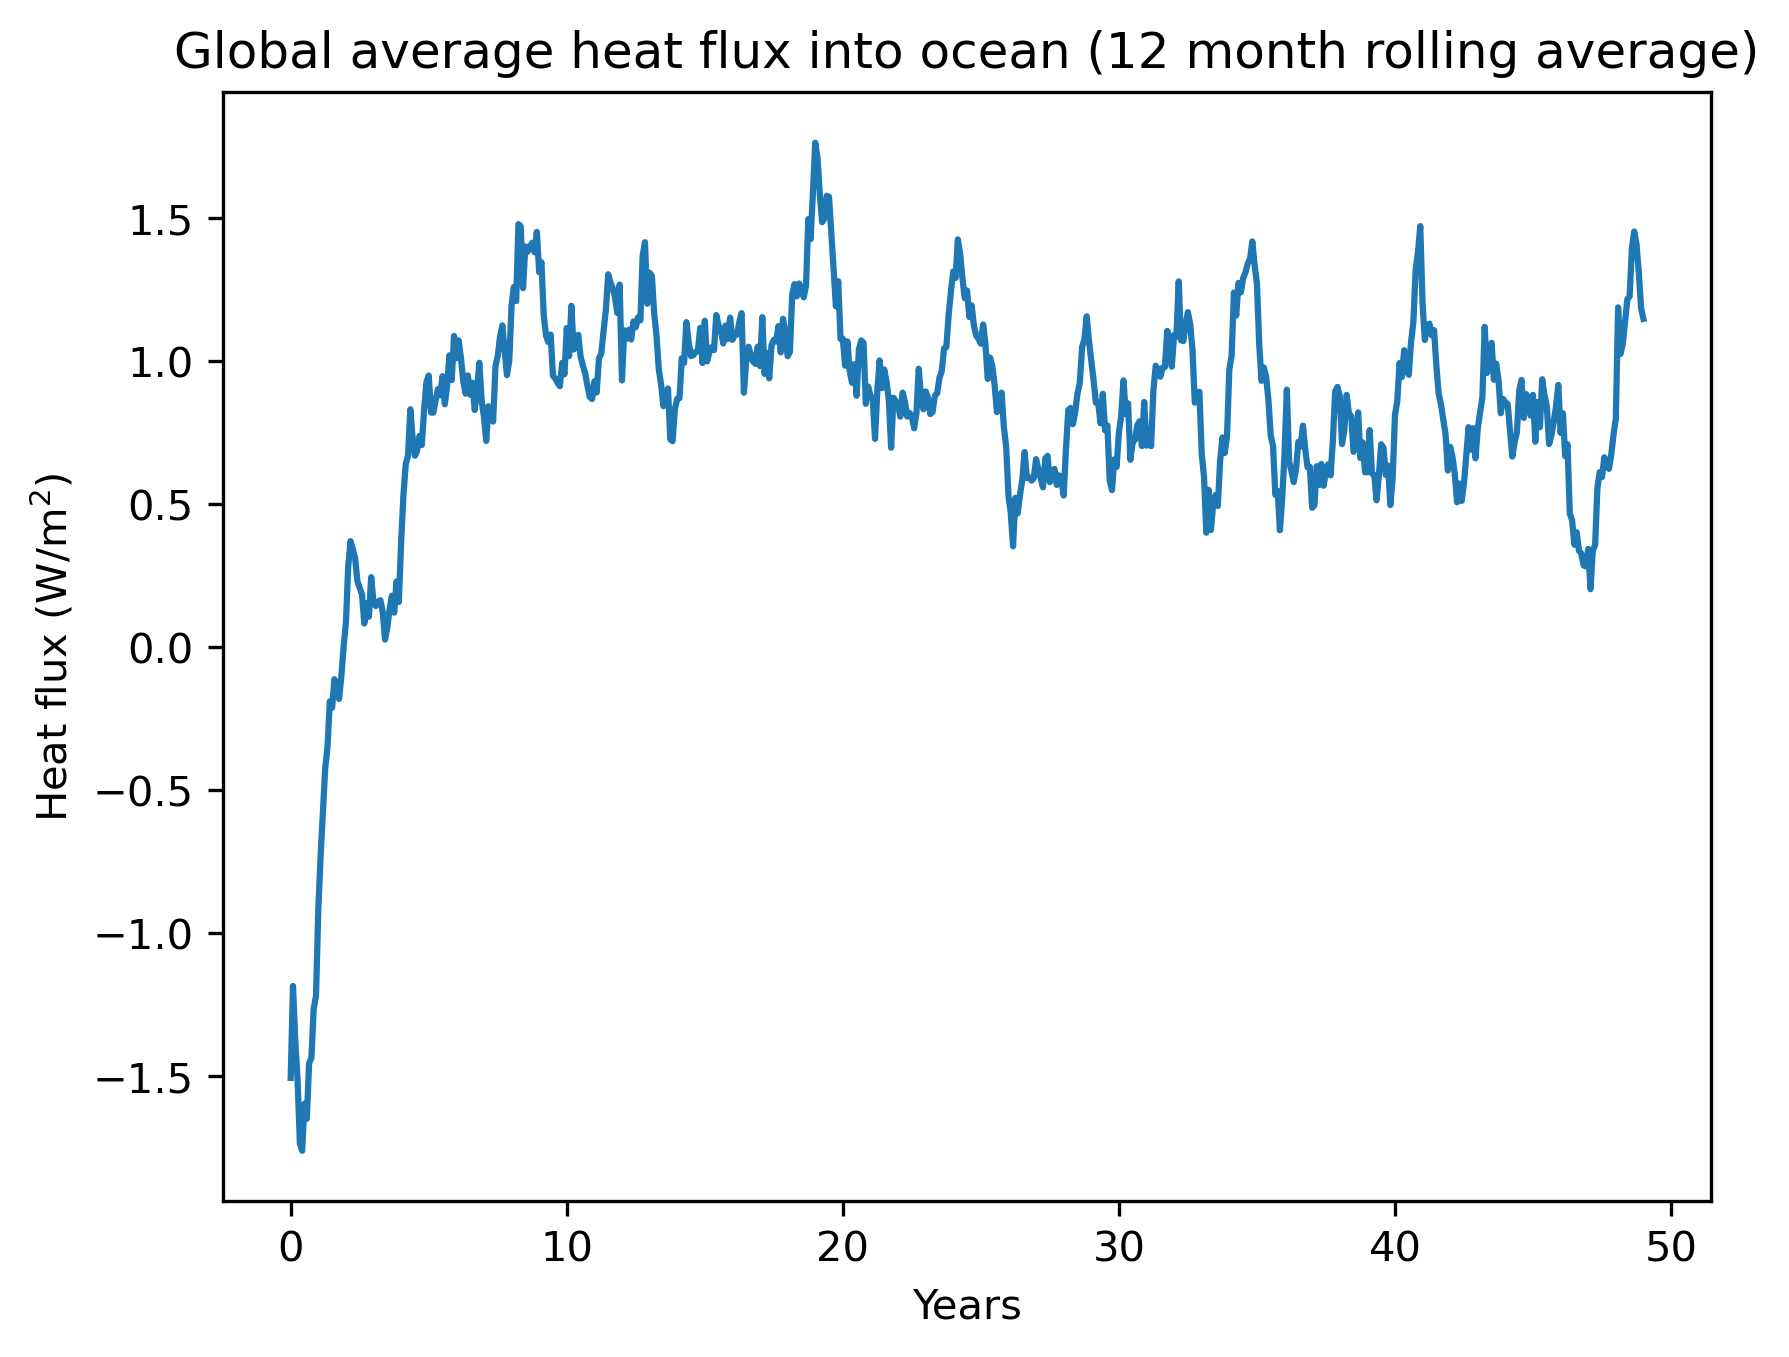

In [22]:
N = 12
rolling_avg = np.convolve(avg_ocean_heatflux, np.ones(N) / N, mode='valid')

plt.title('Global average heat flux into ocean (12 month rolling average)')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg)
plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')

### SST

In [23]:
sst = datastore.search(variable="tos", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).tos

In [24]:
# area weighted average of SST
avg_sst = sst.weighted(areacello.fillna(0)).mean(dim=('yh', 'xh')).compute()

Text(0.5, 0, 'Years')

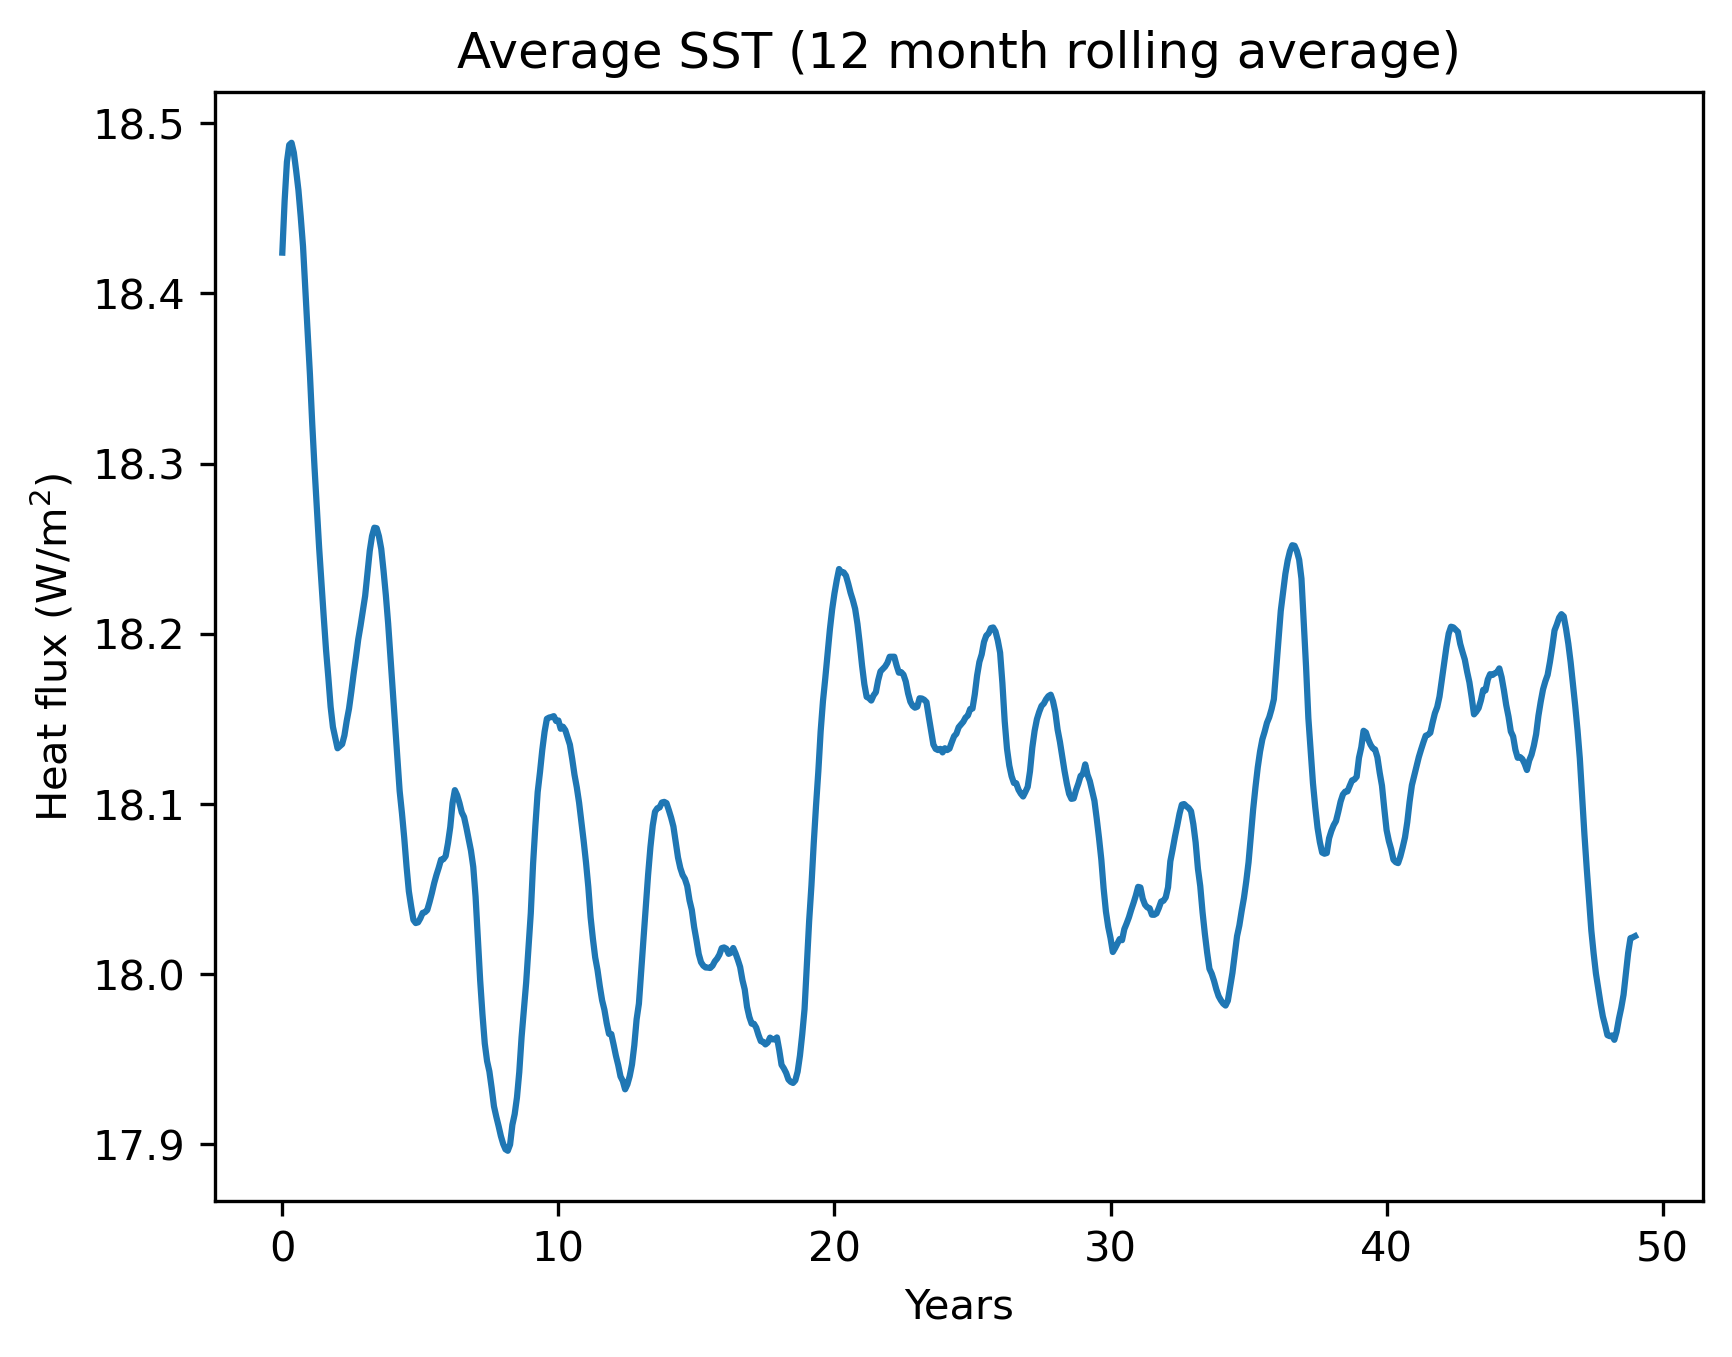

In [25]:
N = 12
rolling_avg = np.convolve(avg_sst, np.ones(N) / N, mode='valid')

plt.title('Average SST (12 month rolling average)')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg)
plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')

# Ice time series

In [10]:
fn = "seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json"
fp = os.path.join(run_dir, 'cm3-demo-datastore', 'virtualised_outputs', fn)
# ice_ds = xr.open_dataset(fp, engine="kerchunk", chunks=dict(time=1, nc=-1, ni=-1, nj=-1))
ice_ds = xr.open_dataset(fp, engine="kerchunk")

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json


In [18]:
# ice_ds.aice_m.data

In [11]:
sh_mask = areacello.data.copy()
sh_mask[sh_mask.data.shape[0]//2:] = 0
sh_mask = xr.DataArray(sh_mask, dims=('nj', 'ni')).fillna(0)

nh_mask = areacello.data.copy()
nh_mask[:nh_mask.data.shape[0]//2] = 0
nh_mask = xr.DataArray(nh_mask, dims=('nj', 'ni')).fillna(0)

In [12]:
%%time
nh_ice_area = ice_ds.aice_m.weighted(nh_mask).sum(dim=('nj', 'ni')).compute()
sh_ice_area = ice_ds.aice_m.weighted(sh_mask).sum(dim=('nj', 'ni')).compute()

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json


CPU times: user 11.4 s, sys: 4.31 s, total: 15.7 s
Wall time: 3min 24s


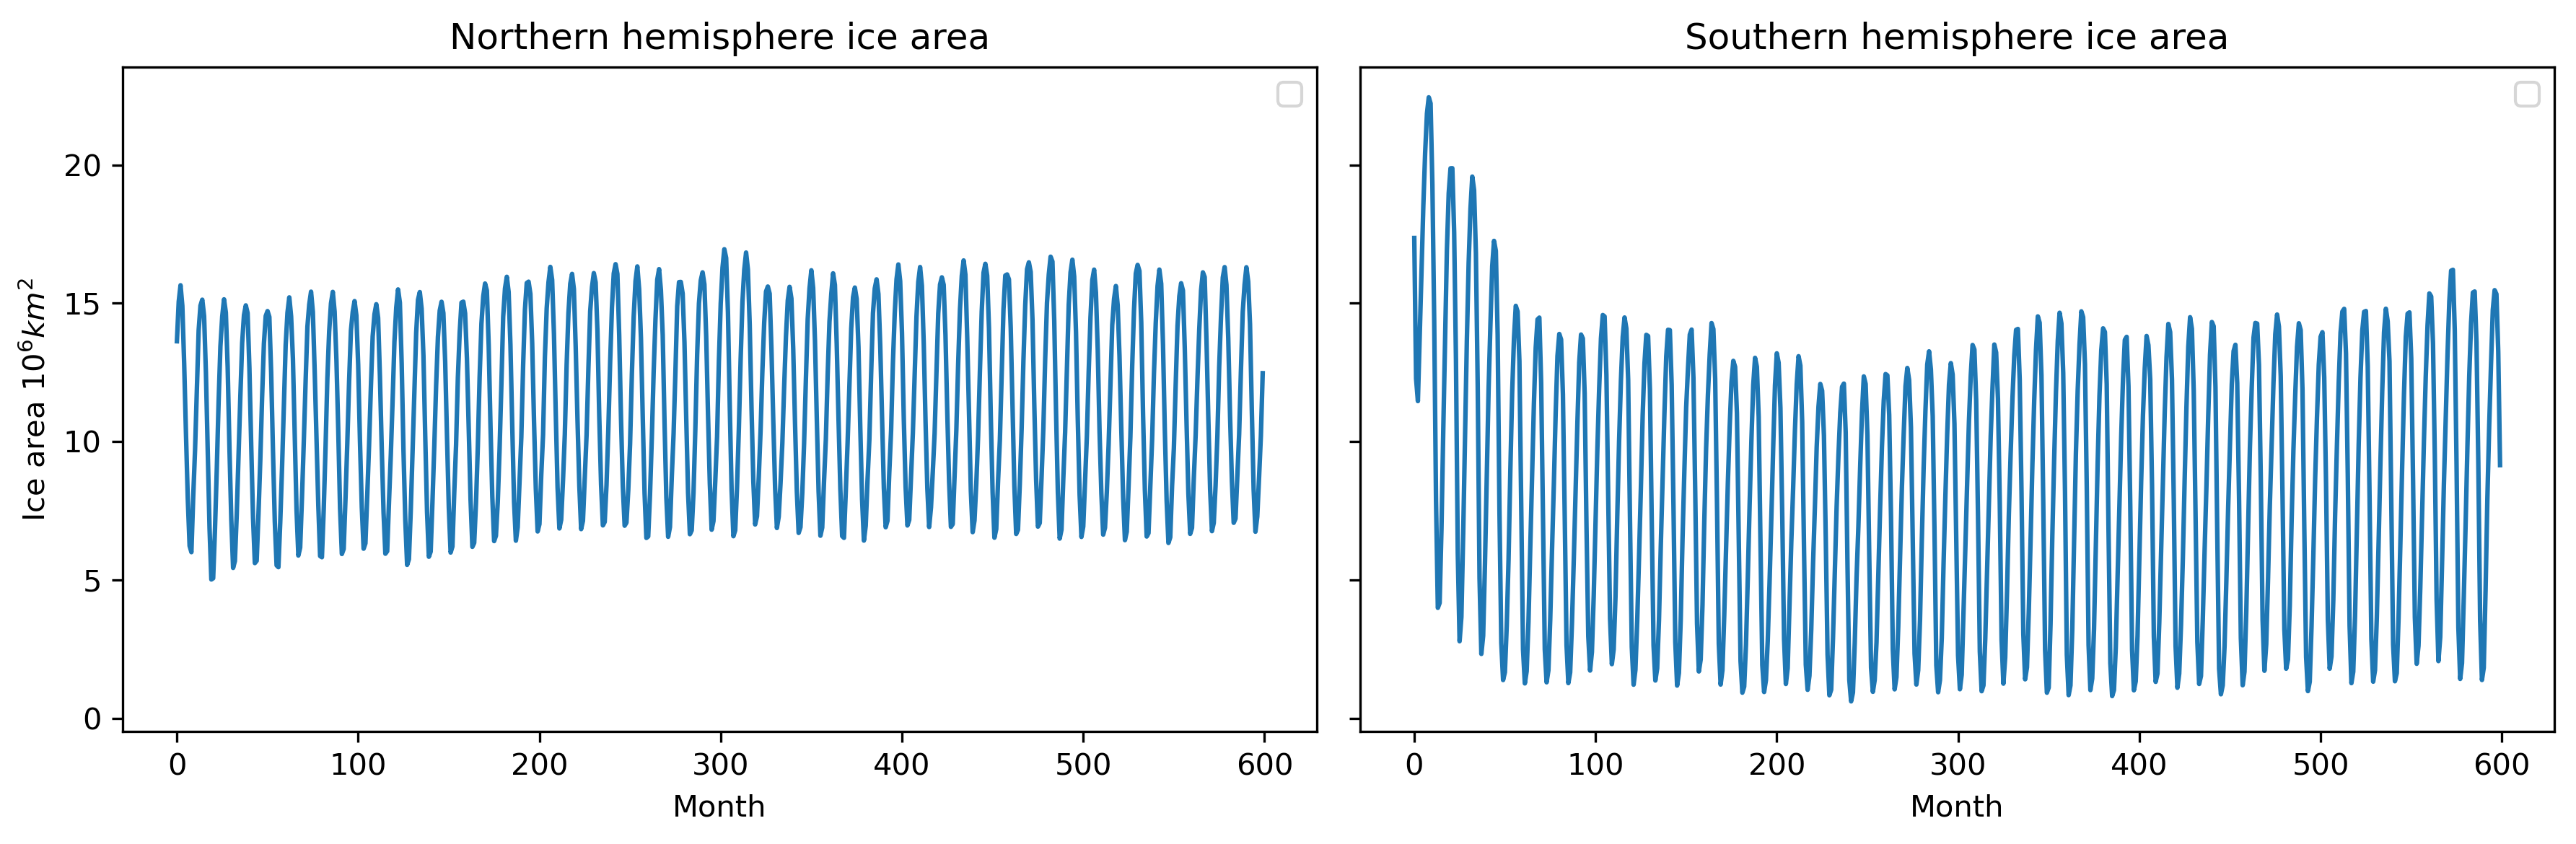

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.plot(nh_ice_area / 1e12)
ax2.plot(sh_ice_area / 1e12)

ax1.set_title('Northern hemisphere ice area')
ax1.set_ylabel('Ice area $10^6 km^2$')
ax1.set_xlabel('Month')
ax1.legend()

ax2.set_title('Southern hemisphere ice area')
ax2.set_xlabel('Month')
ax2.legend()
plt.tight_layout()
plt.savefig('workshop-plots/cm3_ice_area.png')

In [14]:
%%time
nh_ice_vol = ice_ds.vicen_m.weighted(nh_mask).sum(dim=('nc', 'nj', 'ni')).compute()

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json


CPU times: user 32 s, sys: 6 s, total: 38 s
Wall time: 4min 34s


In [15]:
%%time
sh_ice_vol = ice_ds.vicen_m.weighted(sh_mask).sum(dim=('nc', 'nj', 'ni')).compute()

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json


CPU times: user 30.2 s, sys: 5.26 s, total: 35.4 s
Wall time: 3min 59s


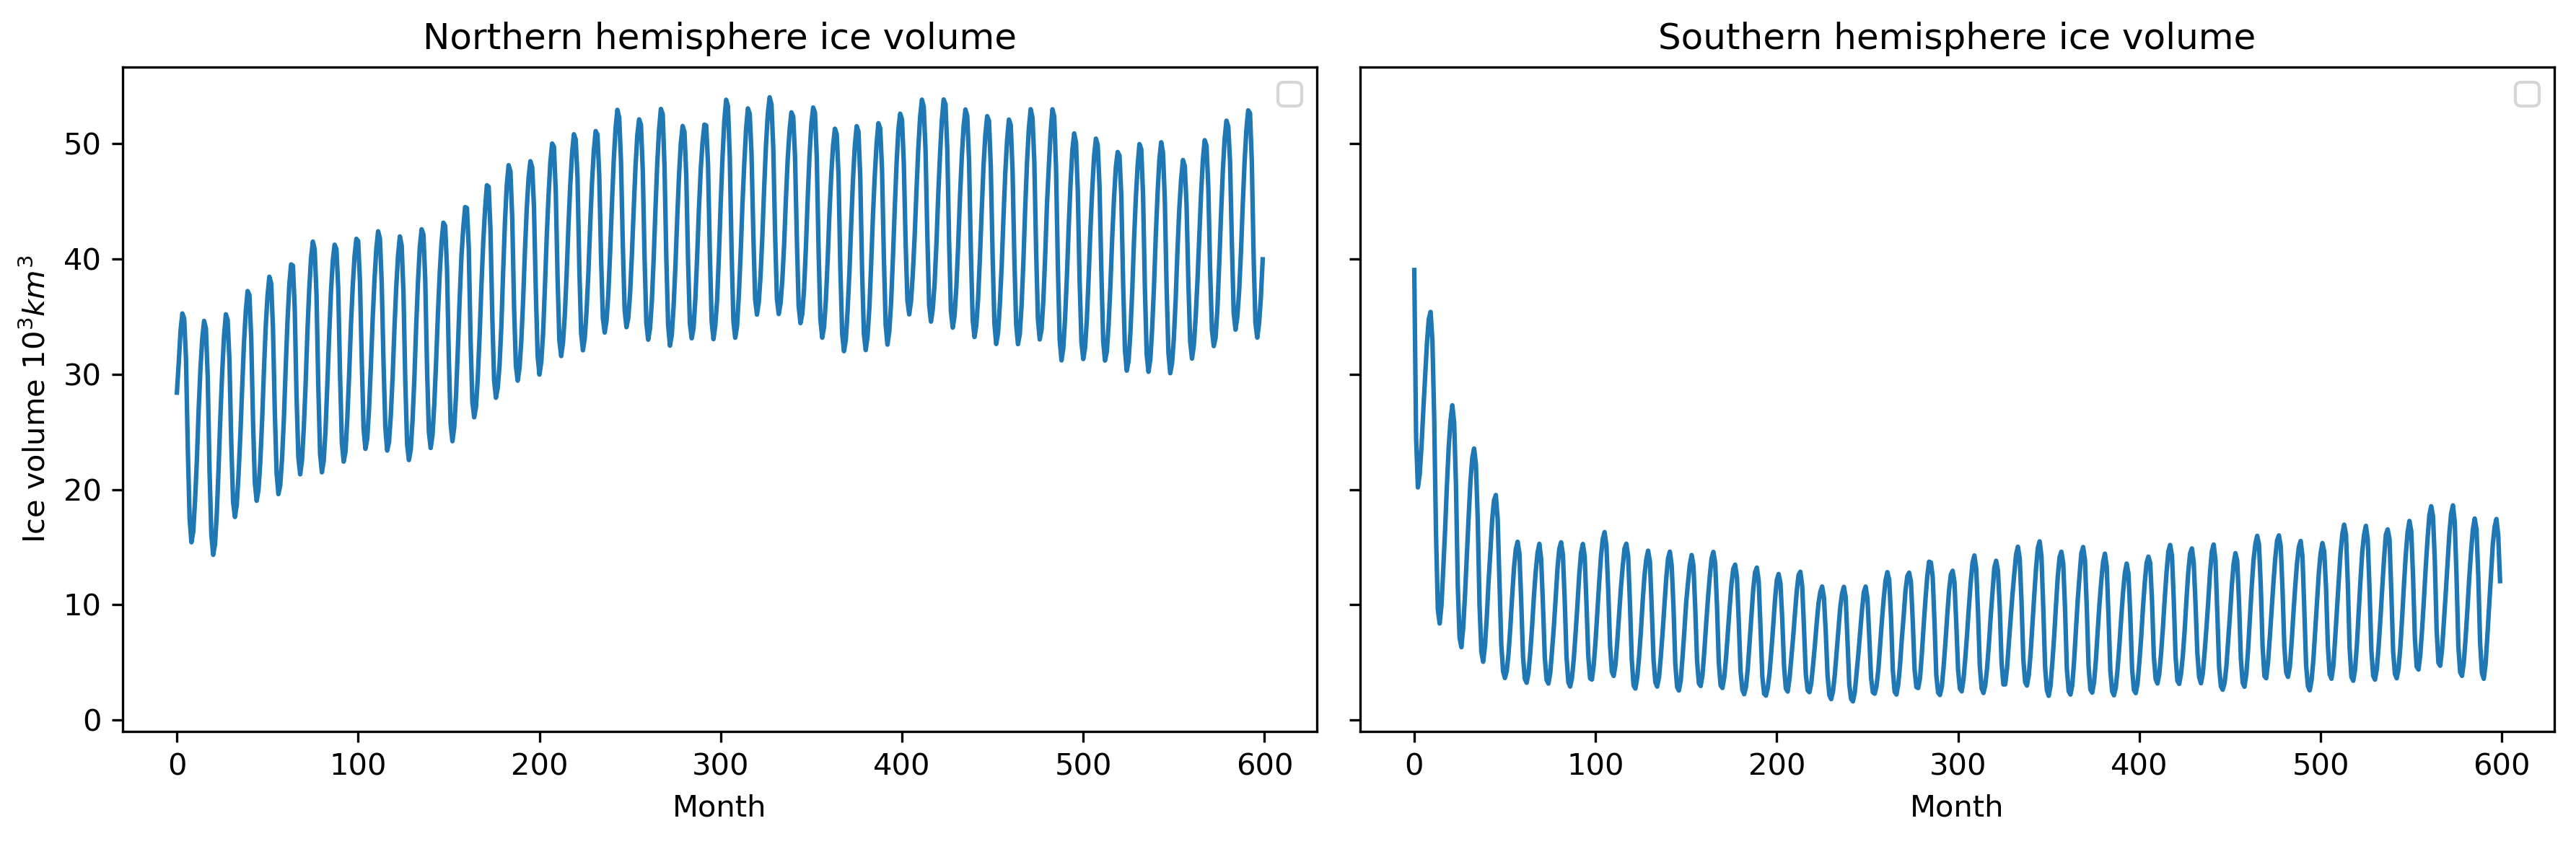

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.plot(nh_ice_vol / 1e12)
ax2.plot(sh_ice_vol / 1e12)

ax1.set_title('Northern hemisphere ice volume')
ax1.set_ylabel('Ice volume $10^3 km^3$')
ax1.set_xlabel('Month')
ax1.legend()

ax2.set_title('Southern hemisphere ice volume')
ax1.set_ylabel('Ice volume $10^3 km^3$')
ax2.set_xlabel('Month')
ax2.legend()
plt.tight_layout()
# plt.savefig('workshop-plots/cm3_ice_vol.png')

# Atmosphere time series

In [26]:
# fn = "atmos.1day.bnds:2.depth:4.lat:144.lat_v:145.lon:192.lon_u:192.model_rho_level_number:52.model_theta_level_number:52.pseudo_level:9.json"
fn = "atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json"
fp = os.path.join(run_dir, 'cm3-demo-datastore', 'virtualised_outputs', fn)
atm_ds = xr.open_dataset(fp, engine="kerchunk")


INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_o

In [27]:
toa = atm_ds.fld_s01i207 - atm_ds.fld_s01i208 - atm_ds.fld_s02i205

In [28]:
avg_toa = toa.weighted(areacella).mean(dim=('lat', 'lon')).compute()

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_o

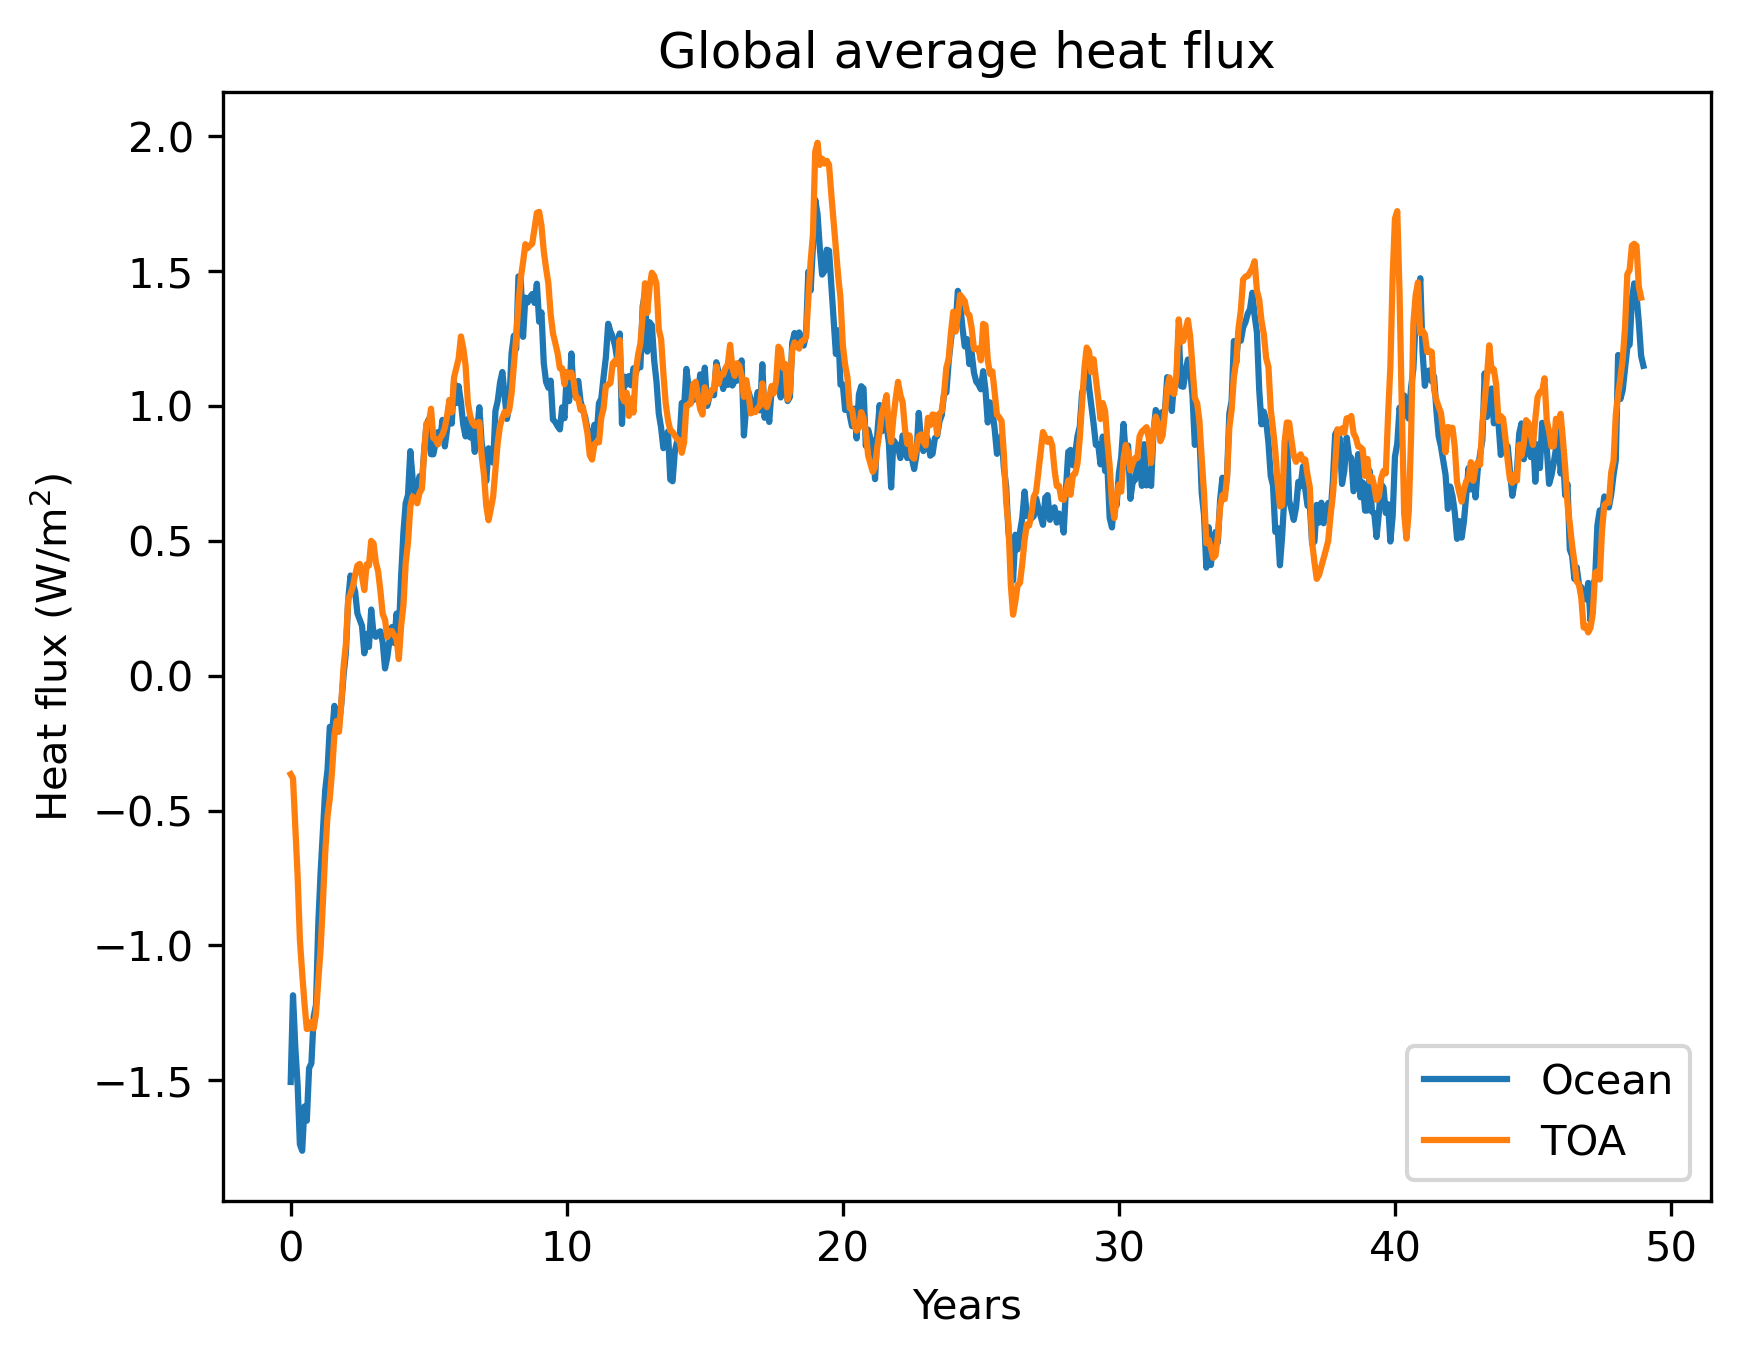

In [29]:
N = 12

rolling_avg = np.convolve(avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label='Ocean')

rolling_avg = np.convolve(avg_toa, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label='TOA')

plt.title('Global average heat flux')

plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')
plt.legend()